<a href="https://colab.research.google.com/github/thered-keep/NCA_Growing/blob/main/nbs/01_LearningToGrow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 1: Learning to Grow

> Conducting the first experiment which involves training the cellular automaton to evolve from an initial seed to the desired shape

In [1]:
!git clone https://github.com/thered-keep/NCA_Growing.git
%cd NCA_Growing

Cloning into 'NCA_Growing'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 131 (delta 25), reused 129 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 27.15 MiB | 21.53 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/NCA_Growing


In [2]:
!pip install -e .

Obtaining file:///content/NCA_Growing
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [3]:
!pip install nbdev

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.1/70.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.3 MB/s eta 0:00:00
  Attempting uninstall: fastcore
    Found existing installation: fastcore 1.7.29
    Uninstalling fastcore-1.7.29:
      Successfully uninstalled fastcore-1.7.29
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.7.19 requires fastcore<1.8,>=1.5.29, but you have fastcore 1.8.1 which is incompatible.


In [4]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| default_exp learning_to_grow

In [5]:
#| export
from NeuralCellularAutomata_PyTorch.core import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

In [9]:
path = './images/emoji_u1f98e.png'

In [6]:
path_start_image= './images/turtle_1.png'

In [13]:
!ls


images	     nbs				      README.md
LICENSE      NeuralCellularAutomata_PyTorch	      settings.ini
MANIFEST.in  NeuralCellularAutomata_PyTorch.egg-info  setup.py


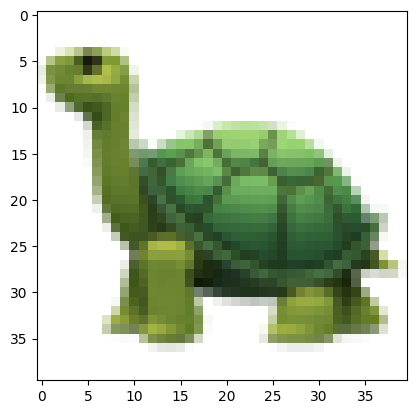

In [7]:
img_tensor_start = load_image(path_start_image)

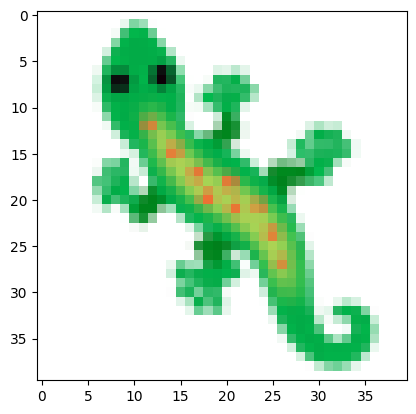

In [10]:
img_tensor = load_image(path)

# Create a starting seed

Create a grid of shape `1, 16, H, W` initialized with zeros, where all elements are set to 0.

Place a single cell in the center of the grid. This central cell should have all channels (except for RGB) set to 1.
The RGB channels of the seed cell are intentionally set to zero to ensure visibility on the white background.

In [ ]:
#| export
seed = torch.zeros(1, 16, TARGET_SIZE, TARGET_SIZE).to(def_device)
seed[:, 3:, TARGET_SIZE//2, TARGET_SIZE//2] = 1.0

In [ ]:
seed.shape

torch.Size([1, 16, 40, 40])

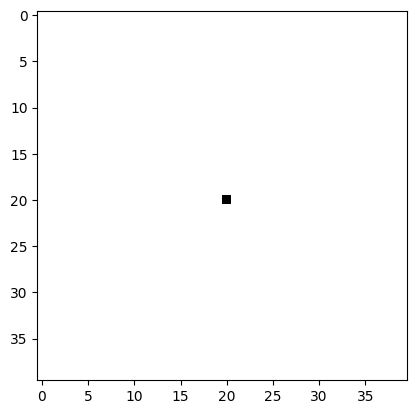

In [ ]:
plt.imshow(seed[0, :4].detach().cpu().permute(1, 2, 0))
plt.show()

## start from anm image

In [11]:
img_tensor_start[0].shape

torch.Size([3, 40, 40])

In [12]:
def make_initial_state_from_image(input_img):
    init_state = torch.zeros(1, 16, TARGET_SIZE, TARGET_SIZE).to(def_device)
    init_state[0, :3] = input_img[0]  # since the batch size is 1 we get the only image and get to extract its RGB.
    init_state[0, 3] = 1.0         # we want the NCA to start from a fully initialized sate of the grid (it inspects all cells)
    return init_state


In [13]:
image_seed= make_initial_state_from_image(img_tensor_start)

In [21]:
image_seed.shape


torch.Size([1, 16, 40, 40])

# Training Loop

In [14]:
#|eval: false


# training hyperparameters
n_epochs = 8000
batch_size = 8

lr = 2e-3
lr_gamma = 0.9999
betas = (0.5, 0.5)

In [15]:
#|eval: false

# initialize the model
ca = CAModel(CHANNEL_N).to(def_device)

In [16]:
#|eval: false


# optimization
import torch.optim as optim

optimizer = torch.optim.Adam(ca.parameters(), lr=lr, betas=betas)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, lr_gamma)

In [17]:
#|eval: false


# create the input to the network and the target
model_in = image_seed.repeat(batch_size, 1, 1, 1)
target = img_tensor.repeat(batch_size, 1, 1, 1)

In [18]:
#|eval: false


for i in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    steps = torch.randint(64, 96, (1,)).item()
    res = ca(model_in, steps=steps)

    loss = F.mse_loss(res[:, :4], target) # we only care about the RGBA channels
    if i%500 == 0:
        print(f"Epoch: {i} Loss: {loss.item()}")
    loss.backward()
    optimizer.step()
    scheduler.step()

  0%|          | 0/8000 [00:00<?, ?it/s]

Epoch: 0 Loss: 0.6105994582176208


  6%|▋         | 502/8000 [01:09<15:03,  8.29it/s]

Epoch: 500 Loss: 0.0029826099053025246


 13%|█▎        | 1002/8000 [02:17<18:06,  6.44it/s]

...

 88%|████████▊ | 7002/8000 [15:44<02:01,  8.24it/s]

Epoch: 7000 Loss: 0.0001697035477263853


 94%|█████████▍| 7501/8000 [16:51<01:08,  7.23it/s]

Epoch: 7500 Loss: 9.049918298842385e-05


100%|██████████| 8000/8000 [17:58<00:00,  7.42it/s]


Test the training process of the network by generating and displaying an animation.

In [24]:
#|eval: false


images = ca.grow_animation(image_seed, 200)
growth_gig=display_animation(images)

As expected, after some time the automato is startig to lose the desired shape.


In [27]:
growth_gig

In [38]:
growth_gig=display_animation(images)

In [42]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   NeuralCellularAutomata_PyTorch/core.py

no changes added to commit (use "git add" and/or "git commit -a")


/content/NCA_Growing
